In [1]:
import os
from langgraph.graph import StateGraph, START,END
from openai import OpenAI
from typing import TypedDict
from dotenv import load_dotenv


In [3]:
load_dotenv()

model = OpenAI(
    base_url="https://router.huggingface.co/v1",
    api_key=os.environ["HF_TOKEN"],
)

In [14]:
# state graph for prompt chaining

class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    evaluation: str

    

In [15]:
def create_outline(state:BlogState)->BlogState:
    title = state['title']

    ## call the llm gen outline 
    prompt = f'Create a detailed outline for a blog post with the title: {title}'

    completion = model.chat.completions.create(
        model="Qwen/Qwen3-8B",
        messages=[
            {
                "role": "user",
                "content": prompt
            },
        ],
    )
    state["outline"] = completion.choices[0].message.content
    return state



In [16]:
def create_blog(state:BlogState)->BlogState:
    title = state['title']
    outline = state['outline']


    ## call the llm gen outline 
    prompt = f'Create a detailed blog post with the title: {title} and the following outline: {outline}'

    completion = model.chat.completions.create(
        model="Qwen/Qwen3-8B",
        messages=[
            {
                "role": "user",
                "content": prompt
            },
        ],
    )
    state["content"] = completion.choices[0].message.content
    return state



In [17]:
def evaluate_blog(state:BlogState)->BlogState:
    title = state['title']
    outline =  state['outline']
    content =  state['content' ]

    prompt = f'Evaluate the following blog post with the title: {title}, outline: {outline}, and content: {content}. Give a score out of 10 and provide feedback for improvement in 30 words.'

    completion = model.chat.completions.create(
        model="Qwen/Qwen3-8B",
        messages=[
            {
                "role": "user",
                "content": prompt
            },
        ],
    )
    state["evaluation"] = completion.choices[0].message.content
    return state

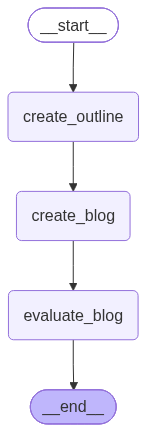

In [20]:
# graph

graph = StateGraph(BlogState)

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluate_blog',evaluate_blog)


graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate_blog')
graph.add_edge('evaluate_blog',END)


workflow = graph.compile()
workflow


In [21]:
initial_state = {"title": "The Future of AI: Trends and Predictions"}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'The Future of AI: Trends and Predictions', 'outline': '\n\n**Title: The Future of AI: Trends and Predictions**  \n\n---\n\n### **Introduction**  \n- **Hook**: Start with a compelling statement about AI’s transformative potential.  \n  *Example:* “Artificial Intelligence is no longer a futuristic dream—it’s reshaping industries, economies, and daily life. But what does the future hold for this revolutionary technology?”  \n- **Purpose**: Explain the blog’s goal: to explore upcoming trends, predictions, and challenges in AI.  \n- **Overview**: Briefly mention key topics covered: breakthroughs, emerging applications, ethical considerations, and societal impact.  \n\n---\n\n### **1. The Current State of AI**  \n- **Recent Advancements**  \n  - Breakthroughs in machine learning, neural networks, and quantum computing.  \n  - Growth of AI-driven technologies (e.g., AI in healthcare, finance, and transportation).  \n- **Key Technologies**  \n  - Generative AI (e.g., GPT-4, DALL-E 3

In [22]:
print(final_state['outline'])



**Title: The Future of AI: Trends and Predictions**  

---

### **Introduction**  
- **Hook**: Start with a compelling statement about AI’s transformative potential.  
  *Example:* “Artificial Intelligence is no longer a futuristic dream—it’s reshaping industries, economies, and daily life. But what does the future hold for this revolutionary technology?”  
- **Purpose**: Explain the blog’s goal: to explore upcoming trends, predictions, and challenges in AI.  
- **Overview**: Briefly mention key topics covered: breakthroughs, emerging applications, ethical considerations, and societal impact.  

---

### **1. The Current State of AI**  
- **Recent Advancements**  
  - Breakthroughs in machine learning, neural networks, and quantum computing.  
  - Growth of AI-driven technologies (e.g., AI in healthcare, finance, and transportation).  
- **Key Technologies**  
  - Generative AI (e.g., GPT-4, DALL-E 3).  
  - Natural Language Processing (NLP) and computer vision.  
  - Edge computing 

In [23]:
print(final_state['content'])



**The Future of AI: Trends and Predictions**  

---

### **Introduction**  
Artificial Intelligence is no longer a futuristic dream—it’s reshaping industries, economies, and daily life. But what does the future hold for this revolutionary technology?  
This blog post explores the latest advancements, emerging trends, and critical challenges in AI, offering a roadmap of its trajectory. From groundbreaking innovations to ethical dilemmas, we’ll delve into how AI will transform society, the risks it poses, and the opportunities it unlocks.  

Key topics include breakthroughs in AI technology, its expanding applications, ethical considerations, and the societal impact of its rapid evolution. Whether you’re a technologist, policymaker, or curious reader, this post will provide insights into the future of AI and how we can navigate it responsibly.  

---

### **1. The Current State of AI**  
#### **Recent Advancements**  
AI has made strides in **machine learning**, **neural networks**, an

In [24]:
print(final_state['evaluation'])



**Score**: 9/10  
**Feedback**: Clear structure and accessible insights, but could add more concrete examples in challenges, simplify jargon, and strengthen the call to action with actionable steps. Enhance transitions for smoother flow.
